In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Total_Cost,Profit,Year,Month
0,1052,2023-02-03,Bob,north,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2749.50,2304.47,2023,2
1,1093,2023-04-21,Bob,west,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,64878.63,-60494.61,2023,4
2,1015,2023-09-21,David,south,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,7846.80,-3215.57,2023,9
3,1072,2023-08-24,Bob,south,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,168871.17,-166703.23,2023,8
4,1061,2023-03-24,Charlie,east,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,8285.81,-4535.61,2023,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
 14  Total_Cost            1000 non-null   float64
 15  Profit                

In [5]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [6]:
df['Profit_Margin'] = df['Profit'] / df['Sales_Amount']

In [7]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

1000

# Highest_Sales region


In [8]:
query = """
SELECT Region, SUM(Sales_Amount) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

pd.read_sql(query, conn)

,Region,Total_Sales
0,north,1369612.51
1,east,1259792.93
2,west,1235608.93
3,south,1154250.86


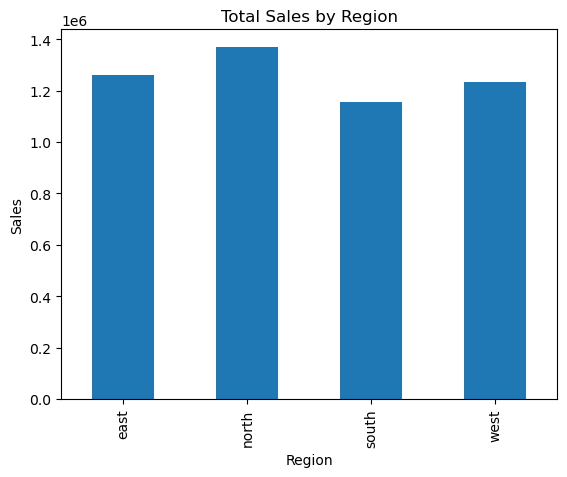

In [9]:
df.groupby('Region')['Sales_Amount'].sum().plot(kind='bar')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

### Insight:
The North region generates the highest revenue, indicating strong market demand and better sales performance compared to other regions.




# Best Product Category

In [10]:
query = """
SELECT Product_Category, SUM(Sales_Amount) AS Total_Sales
FROM sales
GROUP BY Product_Category
ORDER BY Total_Sales DESC;
"""

pd.read_sql(query, conn)

,Product_Category,Total_Sales
0,Clothing,1313474.36
1,Furniture,1260517.69
2,Electronics,1243499.64
3,Food,1201773.54


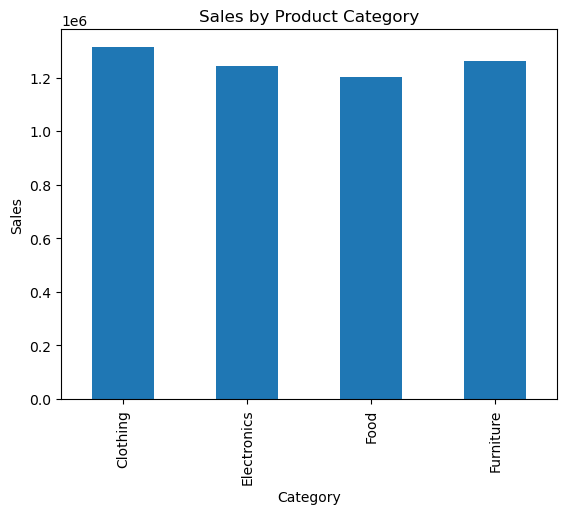

In [11]:
df.groupby('Product_Category')['Sales_Amount'].sum().plot(kind='bar')
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

### Insight:
The Clothing category is the top-performing segment, suggesting higher customer demand and potential for increased focus in this category.

# Monthly Sales Trends


In [12]:
query = """
SELECT Month, SUM(Sales_Amount) AS Monthly_Sales
FROM sales
GROUP BY Month
ORDER BY Month;
"""

pd.read_sql(query, conn)

,Month,Monthly_Sales
0,1,495420.37
1,2,368919.36
2,3,402638.77
3,4,438992.61
4,5,389078.76
5,6,418458.34
6,7,374242.88
7,8,443171.28
8,9,367837.60
9,10,460378.78


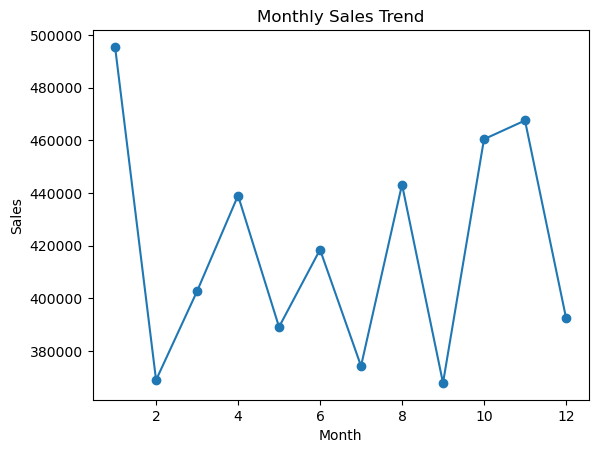

In [13]:
df.groupby('Month')['Sales_Amount'].sum().plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

### Insight:
Sales vary across months, indicating seasonal trends in customer purchasing behavior.

# Top Sales Representatives


In [14]:
query = """
SELECT Sales_Rep, SUM(Sales_Amount) AS Total_Sales
FROM sales
GROUP BY Sales_Rep
ORDER BY Total_Sales DESC;
"""

pd.read_sql(query, conn)

,Sales_Rep,Total_Sales
0,David,1141737.36
1,Bob,1080990.63
2,Eve,970183.99
3,Alice,965541.77
4,Charlie,860811.48


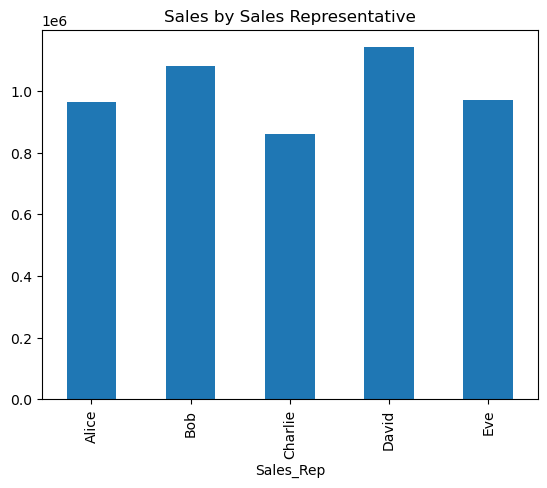

In [15]:
df.groupby('Sales_Rep')['Sales_Amount'].sum().plot(kind='bar')
plt.title('Sales by Sales Representative')
plt.show()

### Insight:
David is the top-performing sales representative, contributing significantly to overall revenue, which reflects strong individual performance.

# Profit by Region

In [16]:
query = """
SELECT Region, SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

pd.read_sql(query, conn)

,Region,Total_Profit
0,south,-13608579.40
1,west,-14869867.95
2,east,-15167050.92
3,north,-15177330.14


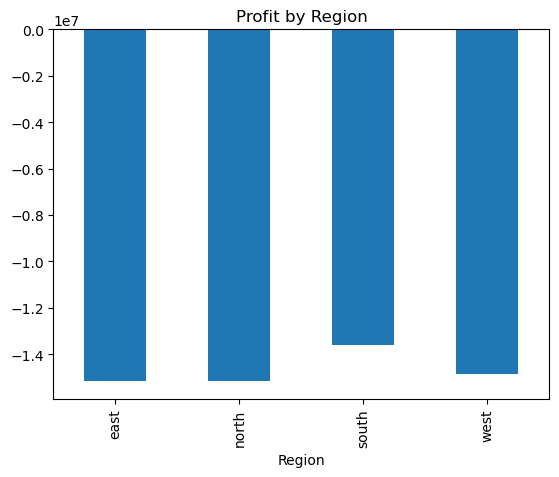

In [17]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Region')
plt.show()

### Insight:
All regions are experiencing losses; however, the South region has the least loss, making it relatively better in terms of profitability.

# Payment Method Analysis

In [18]:
query = """
SELECT Payment_Method, COUNT(*) AS Usage_Count
FROM sales
GROUP BY Payment_Method
ORDER BY Usage_Count DESC;
"""

pd.read_sql(query, conn)

,Payment_Method,Usage_Count
0,Credit Card,345
1,Bank Transfer,342
2,Cash,313


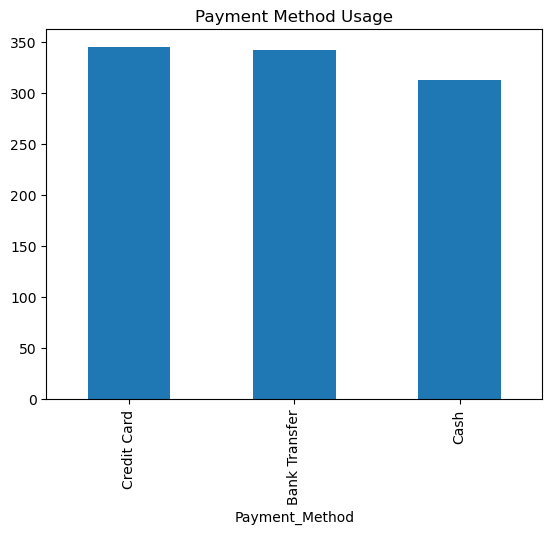

In [19]:
df['Payment_Method'].value_counts().plot(kind='bar')
plt.title('Payment Method Usage')
plt.show()

### Insight:
Credit Card is the most preferred payment method, indicating customer inclination towards digital and convenient payment options.

# Sales Channel Performance


In [20]:
query = """
SELECT Sales_Channel, SUM(Sales_Amount) AS Total_Sales
FROM sales
GROUP BY Sales_Channel;
"""

pd.read_sql(query, conn)

,Sales_Channel,Total_Sales
0,Online,2458833.93
1,Retail,2560431.30


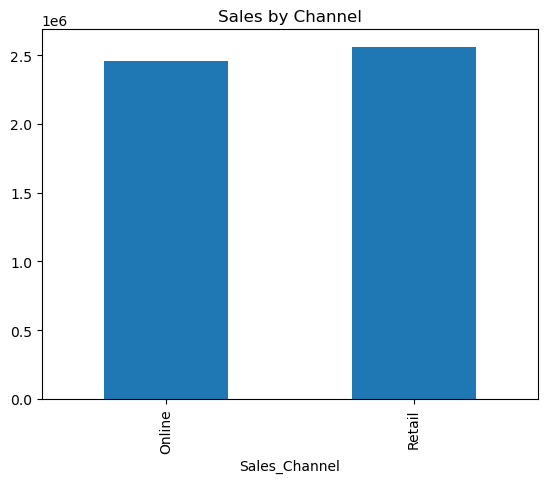

In [21]:
df.groupby('Sales_Channel')['Sales_Amount'].sum().plot(kind='bar')
plt.title('Sales by Channel')
plt.show()

### Insight:
The Retail sales channel generates higher revenue compared to Online, indicating stronger performance in offline sales channels.

# Correlation

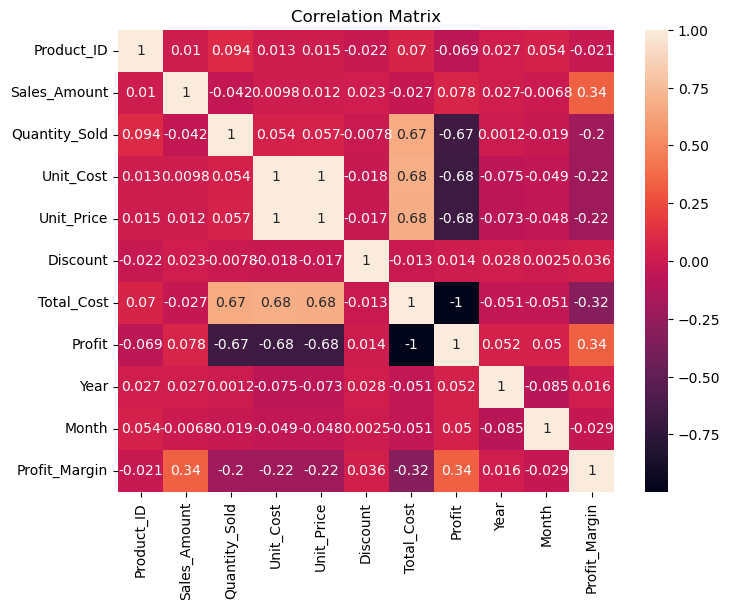

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Matrix')
plt.show()

### Correlation Insight:

Sales Amount is positively related to Quantity Sold and Unit Price, indicating that higher sales volume and pricing increase revenue.

Profit is influenced by both Sales Amount and Total Cost, showing that cost management is crucial for profitability.